In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')



import pandas as pd

dosya_yolu = '/content/data_export_icin.csv'
data = pd.read_csv(dosya_yolu, delimiter=';')



print("-----------------------------------Datamın ilk değerleri------------------------------")
print(data.head())
print ("           ")
print("-----------------------------Data Bilgilerim----------------------------------")
print(data.info())
print ("           ")
print("---------------------------------Describe--------------------------------")
print(data.describe())

Mounted at /content/drive
-----------------------------------Datamın ilk değerleri------------------------------
   id  HbA1c  Hba1c_change  sex  age    LDL  Cholesterol   HDL  Creatinine  \
0   0   10.3      0.234952    1   61  118.0        203.0  55.0        0.71   
1   1    8.3      0.184793    2   65   92.0        189.0  63.0        1.01   
2   2    8.0      0.174650    2   52  107.2        180.0  48.0        1.37   
3   3    7.4     -0.073273    2   55   80.0        168.0  36.0        0.99   
4   4    5.9     -0.031106    1   53  171.0        251.0  58.0        0.77   

   Triglyceride  ...  insulin_reguler  linagliptin  metformin_hcl  nateglinid  \
0         149.0  ...              0.0          0.0           0.00         0.0   
1         253.0  ...              0.0          0.0           0.00         0.0   
2         124.0  ...              0.0          0.0           0.67         0.0   
3         261.0  ...              0.0          0.0           0.00         0.0   
4         112

In [ ]:
print("Eksik veri var mı ")
print(data.isnull().sum())
print("Toplam eksik veri sayisi:")
print(data.isnull().sum().sum())

Eksik veri var mı 
id                  0
HbA1c               0
Hba1c_change        0
sex                 0
age                 0
                   ..
repaglinide         0
saksagliptin        0
sitagliptin         0
vildagliptin        0
Glycemic_control    0
Length: 107, dtype: int64
Toplam eksik veri sayisi:
0


In [ ]:
print("Ana özelliğimin dağılımı ve sayısı")
print(data['Glycemic_control'].value_counts())
print("SATIR,SUTÜN SAYISI")
print(data.shape)

Ana özelliğimin dağılımı ve sayısı
Glycemic_control
1    48933
0    28791
Name: count, dtype: int64
SATIR,SUTÜN SAYISI
(77724, 107)


In [ ]:
import pandas as pd

# Veri tiplerini yazdırmadan önce pandas ayarlarını yapalım
pd.set_option('display.max_columns', None)  # Tüm sütunları göster
pd.set_option('display.max_rows', None)  # Tüm satırları göster (isteğe bağlı)

# Veri tiplerini yazdırma
print(data.dtypes)


id                             int64
HbA1c                        float64
Hba1c_change                 float64
sex                            int64
age                            int64
LDL                          float64
Cholesterol                  float64
HDL                          float64
Creatinine                   float64
Triglyceride                 float64
infectious_diseases            int64
Malign_neoplasms               int64
Obesity                        int64
Thyroid_dis                    int64
neoplasms_unknown              int64
anemia                         int64
vitamin_deficiency             int64
lipoprotein_met_dis            int64
hematologic_dis                int64
endocrine_other                int64
bipolar_affective_dis          int64
depression                     int64
anxiety_dis                    int64
Other_mental_dis               int64
neuropathies                   int64
diabetic_nueropathy            int64
nervous_sys_dis                int64
c

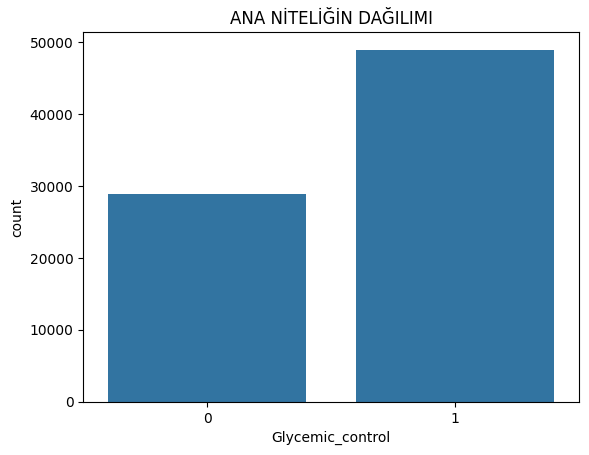

Glycemic Control Yüzdesel Dağılımı (%):
Glycemic_control
1    62.957388
0    37.042612
Name: proportion, dtype: float64


In [ ]:

sns.countplot(x='Glycemic_control', data=data)
plt.title("ANA NİTELİĞİN DAĞILIMI")
plt.show()
ananitelik = data['Glycemic_control'].value_counts(normalize=True) * 100
print("Glycemic Control Yüzdesel Dağılımı (%):")
print(ananitelik)

In [ ]:
#Önemli Değişkenlerin belirlenemesi korelasyonla

corr_matrix = data.corr()
anadegisken_corr = corr_matrix["Glycemic_control"].sort_values(ascending=False)
onemlinitelikler = anadegisken_corr[(anadegisken_corr > 0.1) | (anadegisken_corr < -0.1)]
onemlinitelikler


,Glycemic_control
Glycemic_control,1.000000
HbA1c,0.483635
insulin_glarjin,0.231474
insulin_aspart,0.207398
insulin_detemir,0.137708
gliklazid,0.123547
dapagliflozin,0.115356
retinopathy,0.111010
sitagliptin,0.107980
insulin_lispro,0.104537


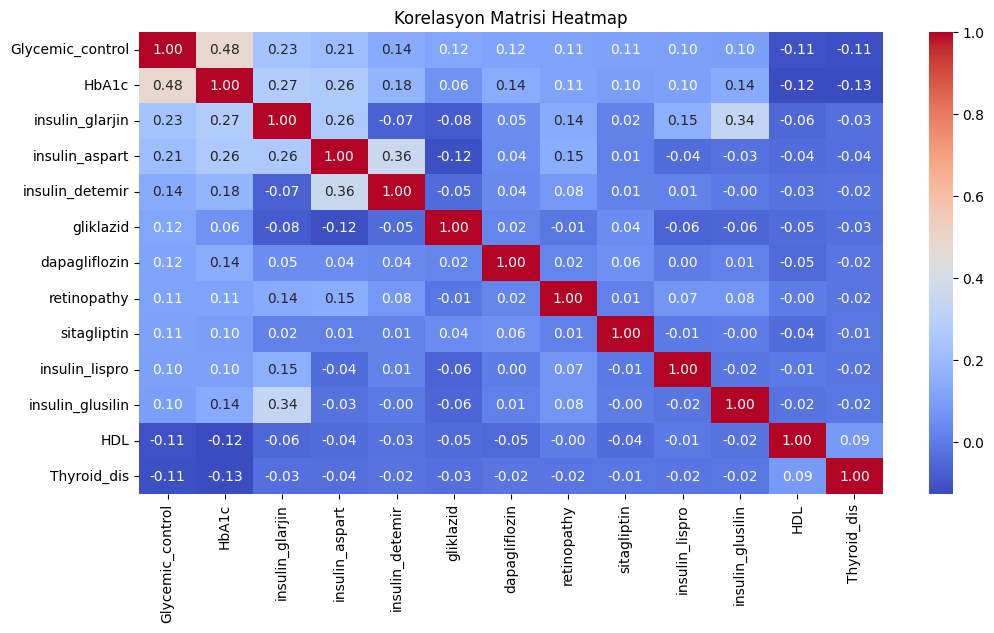

In [ ]:
onemlinitelikler_corr = corr_matrix.loc[onemlinitelikler.index, onemlinitelikler.index]


plt.figure(figsize=(12,6 ))
correlation_matrix = data[data.columns].corr()
sns.heatmap(onemlinitelikler_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasyon Matrisi Heatmap")
plt.show()


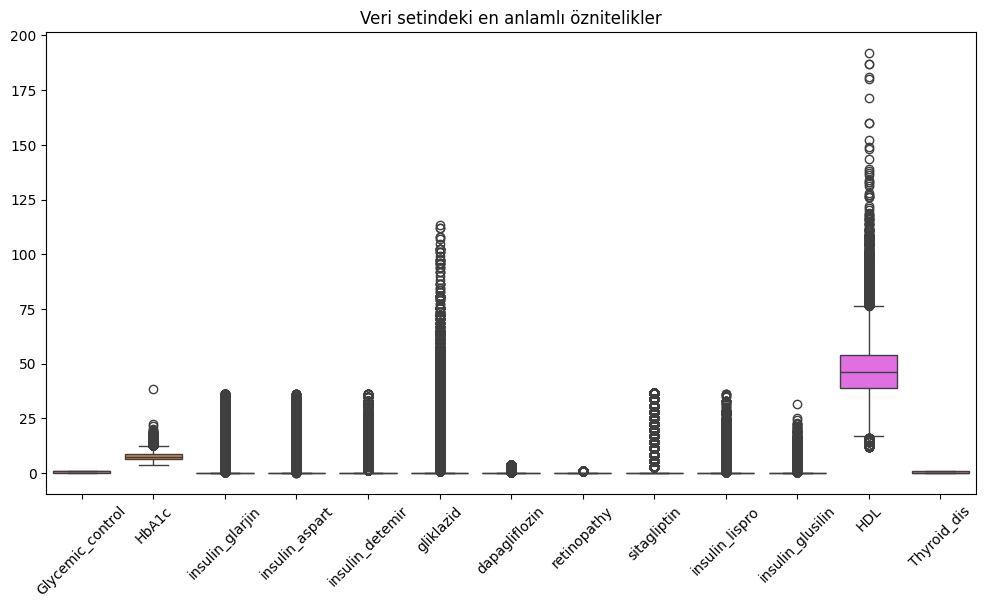

In [ ]:
#önemmli özniteliklerdeki aykırı veriler

onemlinitelikler = onemlinitelikler.index.tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(data=data[onemlinitelikler])
plt.title('Veri setindeki en anlamlı öznitelikler')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from scipy.stats import zscore
from sklearn.impute import KNNImputer

#z skor ile aykırı verileri temizleme
sayisaldegerler = data.select_dtypes(include=['float64', 'int64']).columns
z_scores = data[sayisaldegerler].apply(zscore)
#standart sapma miktarını belirle
threshold = 8
outliers = (z_scores.abs() > threshold).sum()



filtrelenmisdata = data[(z_scores.abs() <= threshold).all(axis=1)]

# Veri kümesinin boyutlarını karşılaştıralım
original_shape = data.shape
filtered_shape = filtrelenmisdata.shape

original_shape, filtered_shape

# Hedef değişkenin dağılımını inceleyin
target_distribution = filtrelenmisdata['Glycemic_control'].value_counts(normalize=True) * 100
filtrelenmisdata=filtrelenmisdata.drop(['id'],axis=1)

# Sonuçları yazdırın
print("Glycemic Control Dağılımı (%):")
print(target_distribution)


Glycemic Control Dağılımı (%):
Glycemic_control
1    62.189349
0    37.810651
Name: proportion, dtype: float64


In [ ]:
#BU VERİLER ÜZERİNDEN ACCURACY DEĞERİNİ YÜKSELTMEYE ÇALIŞTIM

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

X = filtrelenmisdata.drop(['Glycemic_control',], axis=1)
y = filtrelenmisdata['Glycemic_control']

# Veri setinin ölçeklendirilmesiNİ YAPTIM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote_tomek = SMOTETomek(random_state=42, smote=SMOTE(k_neighbors=5))#komşuluk içinde çok değer denedim en iyisi
X_balanced, y_balanced = smote_tomek.fit_resample(X_scaled, y)#iki veriyi örneklerini dengeli hale getirdim.

# Özellik seçtim 50 tane
selector = SelectKBest(f_classif, k=50)  #denemediğim değer kalmadı en yüksek değer bu
X_selected = selector.fit_transform(X_balanced, y_balanced)
# PCA'yı SMOTETomek sonrası verilere uygula
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_balanced)

print("Düzgün PCA sonrası X_pca boyutu:", X_pca.shape)

# Eğitim ve test setine ayırma 30 70 30 test 70 deneme
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_balanced, test_size=0.3, random_state=42)

# denemelik res
model = RandomForestClassifier( random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  #Sadece 1 değerleri için olasılık tahmini yaptım

# Performans değerlendirme
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("-----------------DEGERLER--------------------")
print("Doğruluk:", accuracy)
print("F1 Skoru:", f1)
print("ROC-AUC Skoru:", roc_auc)
print("Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred))
print("SMOTETomek sonrası X_balanced boyutu:", X_balanced.shape)
print("SMOTETomek sonrası y_balanced boyutu:", y_balanced.shape)
print("Özellik seçimi sonrası X_selected boyutu:", X_selected.shape)
print("PCA sonrası X_pca boyutu:", X_pca.shape)
print("Eğitim ve test öncesi X_pca boyutu:", X_pca.shape)
print("Eğitim ve test öncesi y_balanced boyutu:", y_balanced.shape)


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTETomek or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.vali

Düzgün PCA sonrası X_pca boyutu: (84788, 20)
-----------------DEGERLER--------------------
Doğruluk: 0.8578841844557141
F1 Skoru: 0.8578390527948606
ROC-AUC Skoru: 0.9288292839314707
Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.87      0.84      0.85     12649
           1       0.85      0.87      0.86     12788

    accuracy                           0.86     25437
   macro avg       0.86      0.86      0.86     25437
weighted avg       0.86      0.86      0.86     25437

SMOTETomek sonrası X_balanced boyutu: (84788, 105)
SMOTETomek sonrası y_balanced boyutu: (84788,)
Özellik seçimi sonrası X_selected boyutu: (84788, 50)
PCA sonrası X_pca boyutu: (84788, 20)
Eğitim ve test öncesi X_pca boyutu: (84788, 20)
Eğitim ve test öncesi y_balanced boyutu: (84788,)


In [ ]:
print(filtrelenmisdata.tail())
filtrelenmisdata.shape


       HbA1c  Hba1c_change  sex  age      LDL  Cholesterol   HDL  Creatinine  \
77717    7.7      0.187721    1   57   63.000       141.00  47.0        0.70   
77718    7.2      0.112124    1   50  116.000       179.00  34.0        0.66   
77719    8.6      0.488983    1   56   72.000       165.00  64.0        0.59   
77720   10.7     -0.099442    2   62   94.000       152.00  36.0        1.37   
77723    6.3     -0.026083    2   39  106.596       165.97  37.8        0.82   

       Triglyceride  infectious_diseases  Malign_neoplasms  Obesity  \
77717        153.00                    1                 0        0   
77718        144.00                    0                 1        0   
77719        144.00                    0                 0        0   
77720        112.00                    1                 0        0   
77723        107.87                    0                 0        0   

       Thyroid_dis  neoplasms_unknown  anemia  vitamin_deficiency  \
77717            1     

(69290, 106)

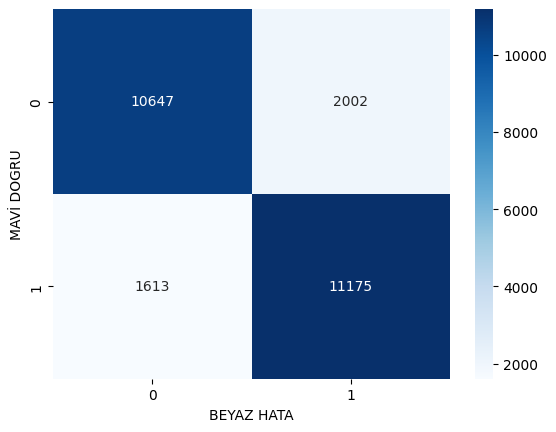

In [ ]:
#Confusion matrix ile tahminleri gösterme
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sonuclar = {}
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("BEYAZ HATA")
plt.ylabel("MAVİ DOGRU")
plt.show()



In [ ]:
print("X boyutu:", X.shape)
print("y boyutu:", y.shape)
print("SMOTETomek sonrası X_balanced boyutu:", X_balanced.shape)
print("SMOTETomek sonrası y_balanced boyutu:", y_balanced.shape)

print("Özellik seçimi sonrası X_selected boyutu:", X_selected.shape)
print("PCA sonrası X_pca boyutu:", X_pca.shape)


X boyutu: (69290, 105)
y boyutu: (69290,)
SMOTETomek sonrası X_balanced boyutu: (84788, 105)
SMOTETomek sonrası y_balanced boyutu: (84788,)
Özellik seçimi sonrası X_selected boyutu: (84788, 50)
PCA sonrası X_pca boyutu: (84788, 20)


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82     12649
           1       0.85      0.77      0.81     12788

    accuracy                           0.82     25437
   macro avg       0.82      0.82      0.82     25437
weighted avg       0.82      0.82      0.82     25437



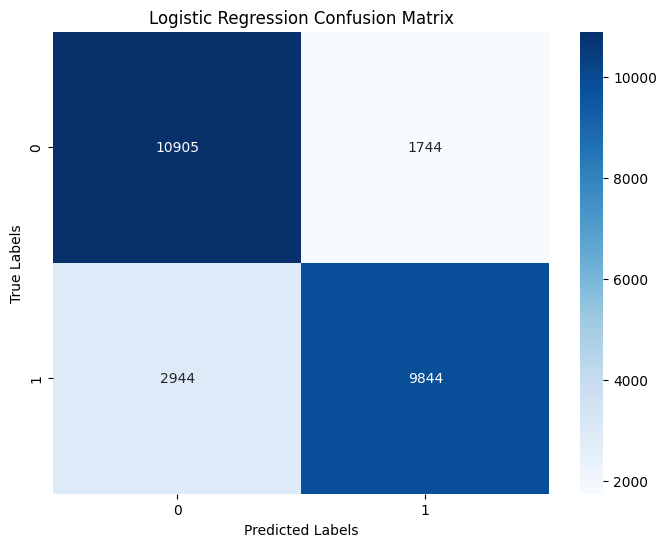

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.88      0.75     12649
           1       0.82      0.55      0.66     12788

    accuracy                           0.72     25437
   macro avg       0.74      0.72      0.71     25437
weighted avg       0.74      0.72      0.71     25437



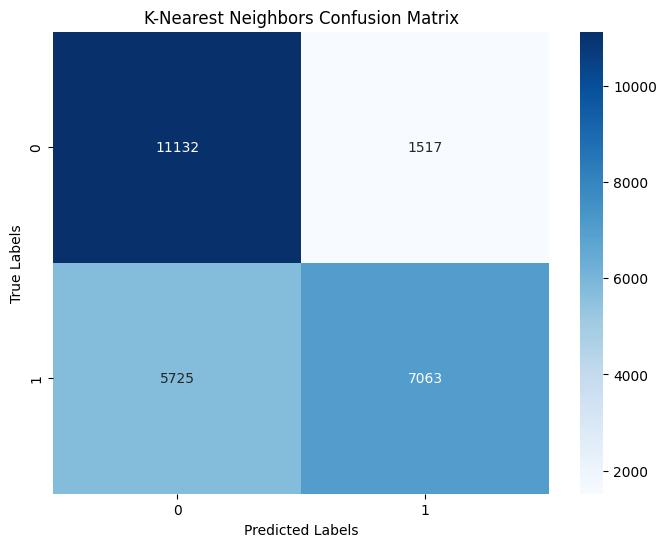

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78     12649
           1       0.78      0.77      0.78     12788

    accuracy                           0.78     25437
   macro avg       0.78      0.78      0.78     25437
weighted avg       0.78      0.78      0.78     25437



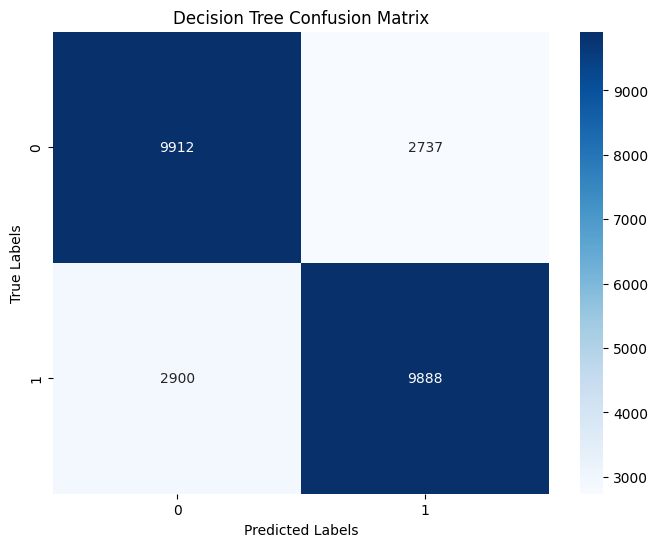

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86     12649
           1       0.85      0.88      0.86     12788

    accuracy                           0.86     25437
   macro avg       0.86      0.86      0.86     25437
weighted avg       0.86      0.86      0.86     25437



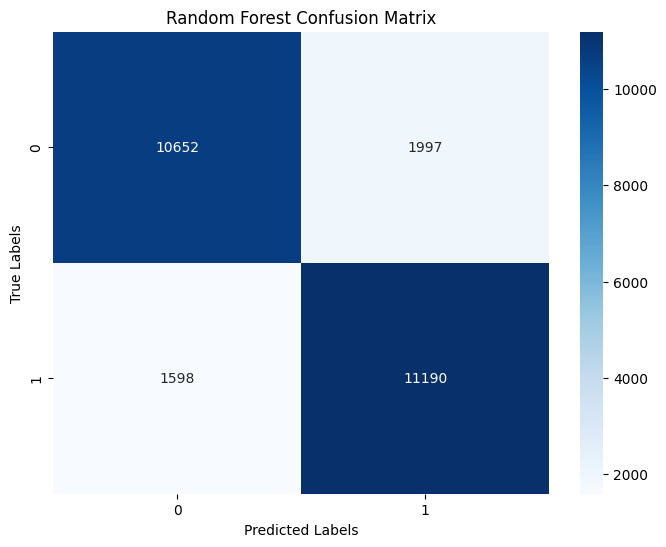

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     12649
           1       0.85      0.86      0.85     12788

    accuracy                           0.85     25437
   macro avg       0.85      0.85      0.85     25437
weighted avg       0.85      0.85      0.85     25437



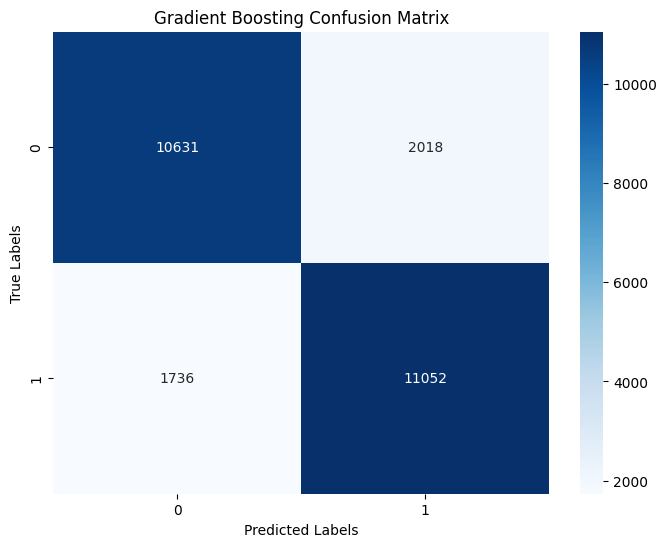

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.85      0.74     12649
           1       0.79      0.57      0.66     12788

    accuracy                           0.71     25437
   macro avg       0.73      0.71      0.70     25437
weighted avg       0.73      0.71      0.70     25437



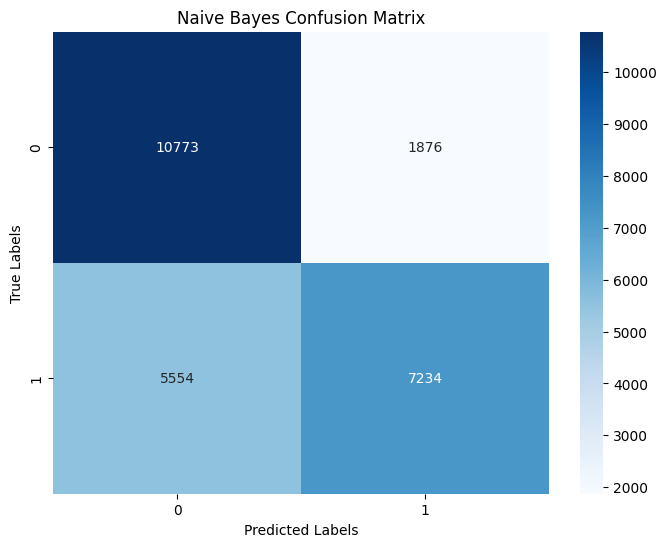

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:51:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86     12649
           1       0.85      0.88      0.86     12788

    accuracy                           0.86     25437
   macro avg       0.86      0.86      0.86     25437
weighted avg       0.86      0.86      0.86     25437



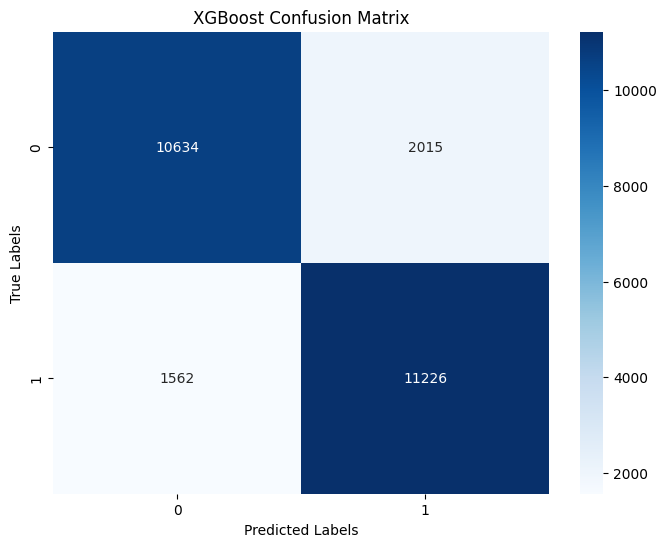

Extra Trees Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.84      0.86     12649
           1       0.85      0.88      0.86     12788

    accuracy                           0.86     25437
   macro avg       0.86      0.86      0.86     25437
weighted avg       0.86      0.86      0.86     25437



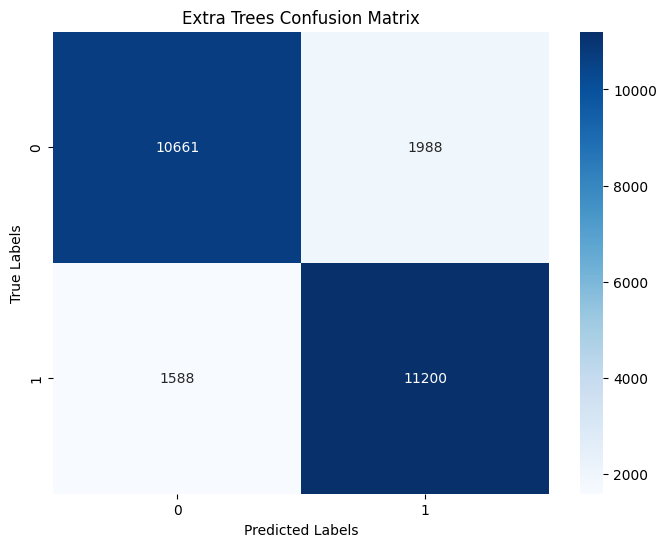

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from joblib import dump
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

# Makine Öğrenimi Modelleri
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Model Tanımları
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Extra Trees": ExtraTreesClassifier()
}

# sonda en iyi değerleri sağlayanı bulmak için kullancam
metrics = []

# Makine Öğrenimi Modellerinin Eğitiminin yapılması
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None# predict_proba  bu metot kullanılarak olasılıklar hesaplanır.ve 1 glyremic için 1 değerleri
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None#y_pred_proba bir değer içeriyorsa (yani None değilse), bu satır ROC AUC değerini hesaplar.
    metrics.append((model_name, accuracy, f1, roc_auc))#metrikleri en iyi seçimi için buraya aldım [] ile tanımladım
    cm = confusion_matrix(y_test, y_pred)
    print(f"{model_name} Classification Report:\n{classification_report(y_test, y_pred)}")
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping



# 1. Temel Sinir Ağı (MLP)

mlp_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mlp_history = mlp_model.fit(X_train, y_train, validation_data=(X_test, y_test),
                            epochs=10, batch_size=64, verbose=1, callbacks=[early_stopping])
mlp_pred_proba = mlp_model.predict(X_test).flatten()
mlp_pred = (mlp_pred_proba > 0.5).astype(int)
mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_f1 = f1_score(y_test, mlp_pred)
mlp_roc_auc = roc_auc_score(y_test, mlp_pred_proba)
metrics.append(("MLP", mlp_accuracy, mlp_f1, mlp_roc_auc))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7591 - loss: 0.5038 - val_accuracy: 0.8234 - val_loss: 0.3997
Epoch 2/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8226 - loss: 0.4069 - val_accuracy: 0.8268 - val_loss: 0.3939
Epoch 3/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8249 - loss: 0.4028 - val_accuracy: 0.8280 - val_loss: 0.3940
Epoch 4/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8279 - loss: 0.3954 - val_accuracy: 0.8285 - val_loss: 0.3929
Epoch 5/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8311 - loss: 0.3895 - val_accuracy: 0.8297 - val_loss: 0.3895
Epoch 6/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8320 - loss: 0.3852 - val_accuracy: 0.8309 - val_loss: 0.3892
Epoch 7/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8329 - loss: 0.3857 - val_accuracy: 0.8299 - val_loss: 0.3917
Epoch 8/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8322 - loss: 0.3845 - val_accuracy: 0.

In [ ]:

# 2. Konvolüsyonel Sinir Ağı (CNN)
X_train_cnn = X_train.reshape(-1, 5, 10, 1)
X_test_cnn = X_test.reshape(-1, 5, 10, 1)
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(5, 10, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_history = cnn_model.fit(X_train_cnn, y_train, validation_data=(X_test_cnn, y_test),
                            epochs=10, batch_size=64, verbose=1, callbacks=[early_stopping])
cnn_pred_proba = cnn_model.predict(X_test_cnn).flatten()
cnn_pred = (cnn_pred_proba > 0.5).astype(int)
cnn_accuracy = accuracy_score(y_test, cnn_pred)
cnn_f1 = f1_score(y_test, cnn_pred)
cnn_roc_auc = roc_auc_score(y_test, cnn_pred_proba)
metrics.append(("CNN", cnn_accuracy, cnn_f1, cnn_roc_auc))

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


928/928 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6668 - loss: 0.6124 - val_accuracy: 0.7407 - val_loss: 0.5294
Epoch 2/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7583 - loss: 0.5121 - val_accuracy: 0.7721 - val_loss: 0.4807
Epoch 3/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7882 - loss: 0.4633 - val_accuracy: 0.7979 - val_loss: 0.4522
Epoch 4/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8011 - loss: 0.4429 - val_accuracy: 0.8051 - val_loss: 0.4307
Epoch 5/10
928/928 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8055 - loss: 0.4305 - val_accuracy: 0.8104 - val_loss: 0.4212
795/795 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Model Karşılaştırması:
MLP: Doğruluk: 0.8334, F1: None, ROC-AUC: 0.90782357254297
CNN: Doğruluk: 0.8067, F1: None, ROC-AUC: 0.8208365665069679


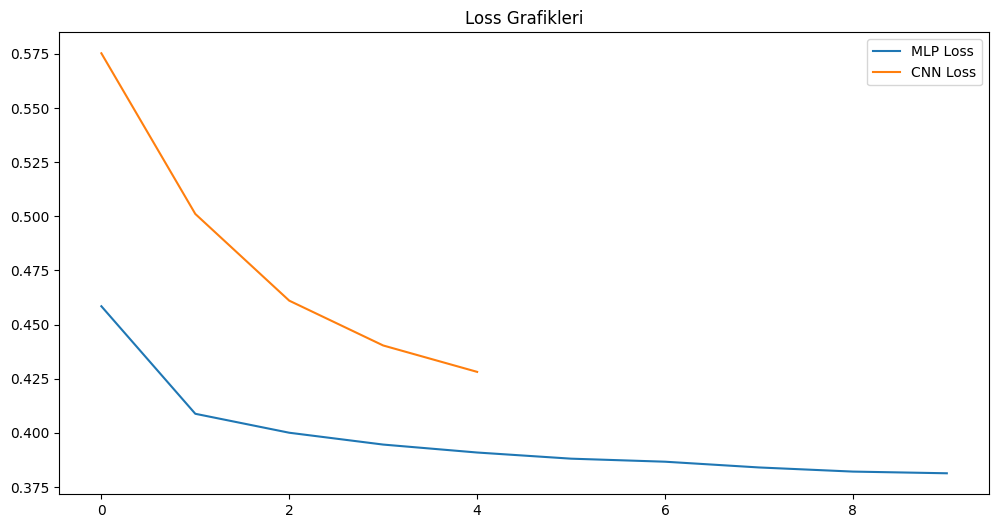

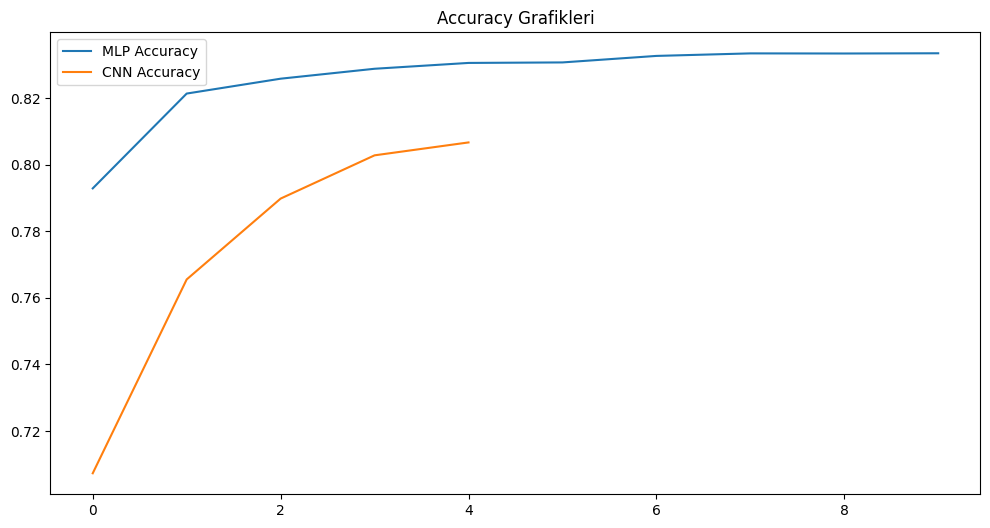

In [ ]:
# Model Karşılaştırması sağlamak amacıyla hücre bloğum
results = {
    "MLP": [mlp_history.history['accuracy'][-1], None, mlp_roc_auc],
    "CNN": [cnn_history.history['accuracy'][-1], None, cnn_roc_auc],
}

print("Model Karşılaştırması:")
for model, metrics in results.items():
    print(f"{model}: Doğruluk: {metrics[0]:.4f}, F1: {metrics[1]}, ROC-AUC: {metrics[2]}")

# Grafiklerin çizdirilmesi
plt.figure(figsize=(10, 5))
plt.plot(mlp_history.history['loss'], label='MLP Loss')
plt.plot(cnn_history.history['loss'], label='CNN Loss')
plt.title('Loss Grafikleri')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(mlp_history.history['accuracy'], label='MLP Accuracy')
plt.plot(cnn_history.history['accuracy'], label='CNN Accuracy')
plt.title('Accuracy Grafikleri')
plt.legend()
plt.show()

In [ ]:
# Performans Tablosu
metrics_df = pd.DataFrame(metrics, columns=["Model", "Accuracy", "F1-Score", "ROC-AUC"])
metrics_df = metrics_df.sort_values(by="Accuracy", ascending=False)

# En İyi Modeli Seçme
best_model_name = metrics_df.loc[metrics_df["Accuracy"].idxmax(), "Model"]
print(f"En iyi modelim: {best_model_name}")

# Makine Öğrenimi Modellerini Kaydetme
if best_model_name in models:
    best_model = models[best_model_name]
    dump(best_model, f"{best_model_name.replace(' ', '_').lower()}_model.joblib")
else:
    # Derin Öğrenme Modelini Kaydetme
    if best_model_name == "MLP":
        mlp_model.save("mlp_model.h5")
    elif best_model_name == "CNN":
        cnn_model.save("cnn_model.h5")

En iyi model: Extra Trees
